In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch
from IPython.display import display  # Per visualizzare tabelle se usi notebook


In [6]:
# === DATASET ===
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Bergantin_Fulvio_42.csv'        #ok
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Cambareri_Chiara_26.csv'        #ok
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Capria_Alessandro_19.csv' 
file_path = r'C:\Users\franc\Desktop\Tesi Magistrale\Materiale_Tesi_SSVEP\Dataset_Originali\EEG_Capria_Francesco_26.csv'       #ok

#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Cicirelli_Franco_50.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Coppolillo_Erica_25.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Damore_Francesco_45.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_DeMaio_Annarita_34.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Falcone_Alberto_40.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Folino_Gianluigi_52.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Guarascio_Massimo_42.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Guerrieri_Antonio_42.csv'       #ok 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Islam_Md_Babul.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Khan_Irfanullah_33.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Macrì_Davide_44.csv'
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Mariani_Luca_33.csv'       #ok
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Mastroianni_Carlo_53.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Miceli_Massimo_50.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Minici_Marco_29.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Mungari_Simone_26.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Pena_Hindred_27.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Pisani_Sergio_Francesco_40.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Qimeng_Li_37.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Rizzo_Luigi_39.csv'        #ok
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Scala_Francesco_33.csv'         #ok
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Vinci_Andrea_40.csv' 
#file_path = r'C:\Users\franc\Desktop\Tesi_SSVEP\Dataset_Originali\EEG_Zicari_Paolo_51.csv' 

In [7]:
# === PARAMETRI ===
fs = 256  # Frequenza di campionamento in Hz
delay_sec = 1
stim_duration_sec = 7
delay_samples = int(fs * delay_sec)
stim_duration_samples = int(fs * stim_duration_sec)
stim_event_ids = [33024, 33025, 33026, 33027]

# === 1. CARICAMENTO E PULIZIA ===
df = pd.read_csv(file_path)

# Rimuovi tutte le righe precedenti all'inizio dell'esperimento (Event Id = 32769)
start_exp_idx = df[df["Event Id"] == 32769].index.min()
if pd.notna(start_exp_idx):
    df = df.loc[start_exp_idx:].reset_index(drop=True)


# Elimina colonne non necessarie
columns_to_drop = [
    "Epoch", "Event Date", "Event Duration",
    "Channel 1", "Channel 2", "Channel 3", "Channel 4",
    "Channel 5", "Channel 6", "Channel 7", "Channel 8"
]
df.drop(columns=columns_to_drop, inplace=True, errors="ignore")

# Rinomina i canali rimanenti
df.rename(columns={
    "Channel 9": "PO7",
    "Channel 10": "O1",
    "Channel 11": "O2",
    "Channel 12": "PO8"
}, inplace=True)

# === 2. ESTENSIONE EVENTI CON RITARDO ===
df_filled = df.copy()
stim_indices = df[df["Event Id"].isin(stim_event_ids)].index

for idx in stim_indices:
    stim_id = df.loc[idx, "Event Id"]
    df_filled.at[idx, "Event Id"] = np.nan  # Rimuove evento dalla riga attuale
    start = idx + delay_samples
    end = start + stim_duration_samples
    df_filled.loc[start:end - 1, "Event Id"] = stim_id  # Inserisce stimolo dopo 1s per 7s
    df_filled.at[end, "Event Id"] = np.nan  # Rimuove evento dalla riga attuale

df_filled["Event Id"] = df_filled["Event Id"].fillna(0)

# Plot Dataset
display(df_filled.head(10))
df_filled.to_csv("psd_features.csv", index=False)
df_filled.shape

,Time:256Hz,PO7,O1,O2,PO8,Event Id
0,127.679688,3306.632568,21710.687500,20826.107422,25802.125000,32769.0
1,127.683594,3253.350098,21632.583984,20768.117188,25753.611328,0.0
2,127.687500,3173.384033,21517.597656,20707.972656,25717.570312,0.0
3,127.691406,3168.297852,21509.798828,20719.445312,25737.318359,0.0
4,127.695312,3228.637451,21593.123047,20772.253906,25777.544922,0.0
5,127.699219,3300.292969,21695.623047,20824.976562,25802.208984,0.0
6,127.703125,3290.911865,21682.214844,20801.333984,25771.765625,0.0
7,127.707031,3204.058838,21554.101562,20726.466797,25722.511719,0.0
8,127.710938,3164.805664,21495.964844,20706.718750,25726.513672,0.0
9,127.714844,3231.825439,21594.535156,20769.990234,25777.167969,0.0


(98770, 6)

In [8]:
# === 4. DEFINIZIONE E APPLICAZIONE FILTRI ===

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    return butter(order, [low, high], btype='band')

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return filtfilt(b, a, data)

def notch_filter(data, fs, notch_freq=50.0, quality_factor=30.0):
    b, a = iirnotch(notch_freq, quality_factor, fs)
    return filtfilt(b, a, data)

# Parametri Filtri
lowcut = 6
highcut = 30
notch_freq = 50.0
quality_factor = 30.0


,PO7_f1,PO7_f2,PO7_f3,PO7_f4,PO7_f5,PO7_f6,PO7_f7,PO7_f8,PO7_f9,PO7_f10,...,PO8_f42,PO8_f43,PO8_f44,PO8_f45,PO8_f46,PO8_f47,PO8_f48,PO8_f49,PO8_f50,Event Id
0,0.177709,0.081431,0.000186,0.001416,0.011051,0.043357,1.034208,2.042023,1.235461,0.574769,...,0.000055,0.000139,0.000042,0.000008,0.000002,0.000002,1.688717e-06,1.546252e-06,1.835406e-06,0.0
1,0.147977,0.067572,0.000208,0.000682,0.003438,0.107418,1.517316,2.405890,1.531884,0.680320,...,0.000130,0.000202,0.000040,0.000010,0.000002,0.000002,1.659898e-06,7.268081e-07,2.834629e-06,0.0
2,0.238195,0.108501,0.000316,0.001123,0.010338,0.175876,1.272277,3.322842,1.835749,0.454364,...,0.000237,0.000292,0.000040,0.000010,0.000002,0.000002,3.031188e-06,9.178265e-07,2.864331e-06,0.0
3,0.177080,0.082220,0.000141,0.000671,0.009977,0.181271,1.054150,3.065968,2.147568,0.557898,...,0.000250,0.000294,0.000044,0.000014,0.000008,0.000009,7.323572e-06,2.557111e-06,3.891968e-06,0.0
4,0.193390,0.090326,0.000141,0.000602,0.014717,0.264984,1.252354,2.818716,2.129898,0.728613,...,0.000257,0.000261,0.000037,0.000019,0.000017,0.000014,8.405265e-06,3.733145e-06,6.427330e-07,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.213548,0.096698,0.000317,0.001440,0.008839,0.260607,0.672892,0.545466,0.494038,1.262977,...,0.000064,0.000050,0.000026,0.000011,0.000006,0.000004,2.810661e-06,1.388387e-06,2.711070e-06,0.0
96,0.112585,0.051996,0.000114,0.000704,0.005561,0.192167,0.804154,0.795611,0.727269,0.949725,...,0.000069,0.000038,0.000028,0.000011,0.000008,0.000004,2.984178e-06,1.545017e-06,3.472374e-06,0.0
97,0.118733,0.055056,0.000113,0.000547,0.004914,0.204371,0.680845,0.967033,1.094144,0.908763,...,0.000054,0.000026,0.000026,0.000012,0.000009,0.000004,2.394500e-06,7.107844e-07,1.171922e-06,0.0
98,0.188154,0.086201,0.000236,0.000713,0.003473,0.186664,0.755656,2.418641,2.311601,0.882910,...,0.000043,0.000030,0.000023,0.000012,0.000011,0.000003,7.498813e-07,6.803667e-07,5.383111e-06,0.0


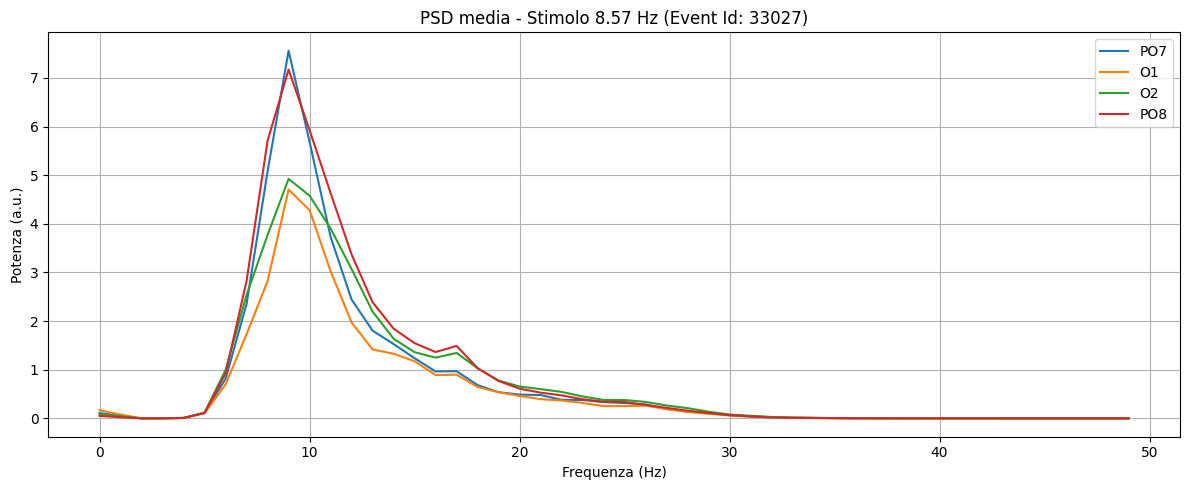

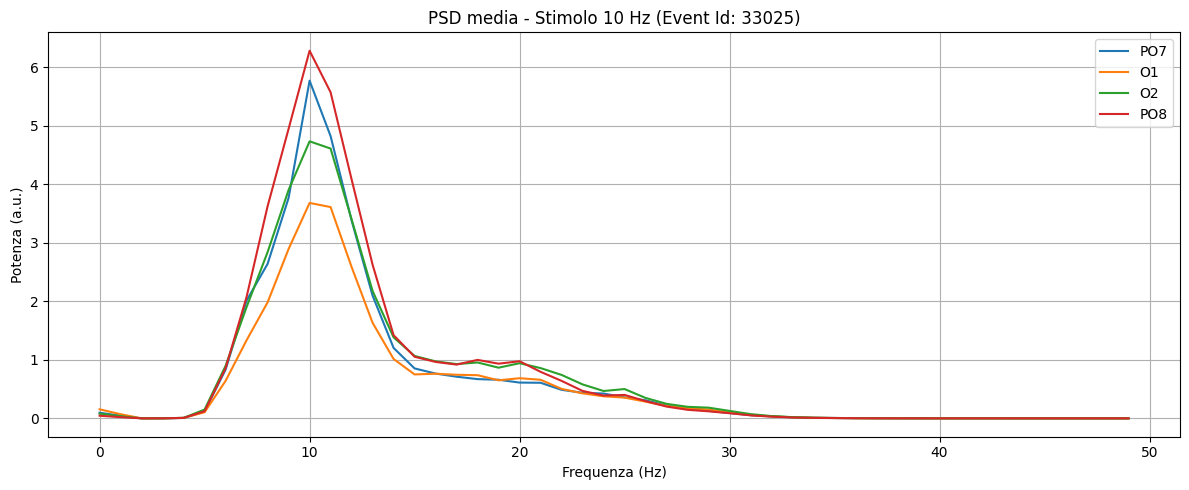

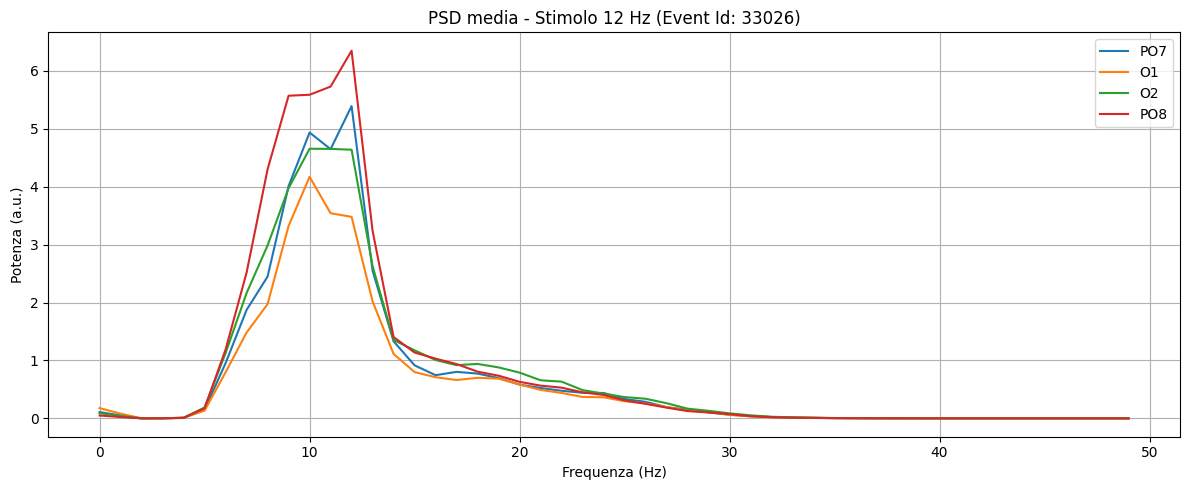

In [9]:
# === 5. CALCOLO PSD SULLA FINESTRA ===

W = 512        # finestra di 2 secondi
S = 64        # scorrimento (0.25 s)
channels = ["PO7", "O1", "O2", "PO8"]
nfft = W
max_freq = 50

psd_features = []
labels = []
freqs = []

for start in range(0, len(df_filled) - W + 1, S):
    end = start + W
    window = df_filled.iloc[start:end]

    feature_vector = []
    for ch in channels:
        signal = window[ch].values
        #print(len(signal))
        bandpassed = bandpass_filter(signal, lowcut, highcut, fs)
        filtered = notch_filter(bandpassed, fs, notch_freq, quality_factor)        
        freqs, psd = welch(filtered, fs=fs, nperseg=256, noverlap=192)
        feature_vector.extend(psd[:50])  # 50 valori PSD per canale


    event_id = window["Event Id"].iloc[-1]
    psd_features.append(feature_vector)
    labels.append(event_id)

# Tabella delle Feature
column_names = [f"{ch}_f{i+1}" for ch in channels for i in range(50)]
psd_df = pd.DataFrame(psd_features, columns=column_names)
psd_df["Event Id"] = labels


### --- PLOT PSD --- ####

# Plot Dataset in Frequenza
# Ogni Riga del Dataset è una finestra, e contiene 201 elementi, così divisi:
# 50: PO7 dalla Frequenza 1 a 50
# 50: O1 dalla Frequenza 1 a 50
# 50: O2 dalla Frequenza 1 a 50
# 50: PO8 dalla Frequenza 1 a 50
# 1:  Event Id dell'ultimo elemento della finestra
display(psd_df.head(100))  # Prime 100 Righe


# Plot PSD Media per ogni Evento
stim_labels = {
    0: "Standby",
    33024: "Nessuno stimolo",
    33025: "Stimolo 10 Hz",
    33026: "Stimolo 12 Hz",
    33027: "Stimolo 8.57 Hz"
}

def plot_psd_media(event_id):
    if event_id not in stim_labels:
        print(f"⚠️ Event Id {event_id} non valido.")
        return

    stim_df = psd_df[psd_df["Event Id"] == event_id]
    if stim_df.empty:
        print(f"Nessuna finestra trovata per Event Id {event_id}")
        return

    plt.figure(figsize=(12, 5))
    for ch in channels:
        cols = [f"{ch}_f{i+1}" for i in range(50)]
        psd_vals = stim_df[cols].mean().values
        plt.plot(freqs[:50], psd_vals, label=ch)

    plt.title(f"PSD media - {stim_labels[event_id]} (Event Id: {event_id})")
    plt.xlabel("Frequenza (Hz)")
    plt.ylabel("Potenza (a.u.)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot Uno alla Volta
plot_psd_media(33027)  # 8.57 Hz
plot_psd_media(33025)  # 10 Hz
plot_psd_media(33026)  # 12 Hz

#psd_df.shape

In [10]:
# === 6. SALVATAGGIO DATASET FINALE ===
# Salvare come "PSD_dataset_Cognome_Nome_età.csv"
# Es: PSD_dataset_Capria_Francesco_26.csv
psd_df.to_csv("PSD_dataset_Capria_Francesco_26.csv", index=False)